# Kernel Swapping Affects Model Performance

---
The availability of compute is a major bottleneck faced by all the AI labs/model providers today. Kernel engineering is a critical component of the model development and deployment process that tries to alleviate the affects of this bottleneck by maximizing the use of underlying GPU acclerators. We've seen a proliferation of open source kernel/inference libraries like Flash-Attention, Liger-Kernel, Flash-Linear-Attention, vLLM, and flash-infer that provide highly specialized kernels for different operations, workloads, dtypes, and hardware. 

All of these libraries ensure that their kernels are correct by running unit tests that check the outputs of the kernel against a reference implementation within some tolerance (atol/rtol). However, passing these unit tests does not guarantee that the model will behave identically when using the new kernel. 

**Kernel correctness != Model correctness**

### Why does this happen?
The core issue is **error accumulation**. A Transformer is a deep composition of operations across many layers. A tiny floating-point deviation introduced by a swapped kernel in layer 1 doesn't stay tiny or constant; it propagates forward, gets scaled, added to residual streams, normalized again, and amplified through attention and feed-forward projections. _By the final layer, the model may be in a meaningfully different hidden state_, generating different tokens and scoring differently on downstream benchmarks.


In this blog, we'll show that when the `RMSNorm` kernel implemented in the [Transformers](https://github.com/huggingface/transformers) library is replaced with the `RMSNorm` of [Liger-Kernel](https://github.com/linkedin/Liger-Kernel) in a `Qwen3-0.6B` model, there are drifts in the hidden states, probability distributions of output tokens, and a change in the model's performance on a subset of the MMLU-Pro benchmark. 

_The results shown in this blog are based on running the model and kernel on an NVIDIA H100._


## Setup

In [1]:
!uv pip install -q torch transformers liger-kernel datasets matplotlib seaborn numpy tqdm accelerate


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import string
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from liger_kernel.ops.rms_norm import LigerRMSNormFunction

MODEL_NAME = "Qwen/Qwen3-0.6B"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/pramodith/blog/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
PyTorch: 2.11.0+cu130
GPU    : NVIDIA H100 80GB HBM3
VRAM   : 85.0 GB


---

## RMSNorm: The Operation Under the Microscope

Root Mean Square Normalization ([Zhang & Sennrich, 2019](https://arxiv.org/abs/1910.07467)) is the normalization layer of choice in most modern LLMs; Qwen, LLaMA, and Mistral all use it. Its formula is deceptively simple:

$$\text{RMSNorm}(\mathbf{x}) = \frac{\mathbf{x}}{\text{RMS}(\mathbf{x})} \cdot \mathbf{w}, \quad \text{where} \quad \text{RMS}(\mathbf{x}) = \sqrt{\frac{1}{d}\sum_{i=1}^{d} x_i^2 + \epsilon}$$

Unlike LayerNorm, RMSNorm skips the mean-subtraction step, making it cheaper to compute.

The implementation of [RMSNorm](https://github.com/huggingface/transformers/blob/0db33792ed1cc6a61d96f5d59fd0c930db2896fe/src/transformers/models/qwen3/modeling_qwen3.py#L50) in Hugging Face's `transformers` library for the Qwen3 model is shown below:

In [3]:
class Qwen3RMSNorm(nn.Module):
    def __init__(self, hidden_size, eps: float = 1e-6) -> None:
        """
        Qwen3RMSNorm is equivalent to T5LayerNorm
        """
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.variance_epsilon = eps

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        input_dtype = hidden_states.dtype
        hidden_states = hidden_states.to(torch.float32)
        variance = hidden_states.pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        return self.weight * hidden_states.to(input_dtype)

    def extra_repr(self):
        return f"{tuple(self.weight.shape)}, eps={self.variance_epsilon}"

## Dropping In a Custom Kernel

[Liger-Kernel](https://github.com/linkedin/Liger-Kernel) ships fused Triton replacements for standard Transformer ops. These triton kernels are supposed to deliver better speed and/or memory efficiency. We import `LigerRMSNormFunction` directly and use it as a drop-in for `Qwen3RMSNorm.forward`:

In [4]:
liger_kernel_rmsnorm = LigerRMSNormFunction.apply

---

## Part 1: Correctness Tests
The standard way to validate a custom kernel is to compare its outputs against a reference implementation on random inputs, within some numerical tolerance. This is the test that would appear in a kernel's CI suite. It's nearly impossible to get bitwise identical outputs from two different implementations of the same operation because floating point arithmetic is not associative. i.e. _(A + B) + C != A + (B + C)_. So instead, we check that the outputs are close within some `atol` and `rtol` thresholds.

We'll test across `float32` and `bfloat16`, using `atol=1e-3, rtol=1e-3`, a reasonable tolerance for mixed-precision arithmetic:

In [5]:
def test_kernel_correctness(
    kernel, dtype: torch.dtype, hidden_size: int = 1024,
    atol: float = 1e-3, rtol: float = 1e-3, seed: int = 42
):
    torch.manual_seed(seed)
    batch, seq_len = 2, 16

    hidden_states = torch.randn(batch, seq_len, hidden_size, dtype=dtype, device=DEVICE)
    weight = torch.randn(hidden_size, dtype=dtype, device=DEVICE)
    eps = 1e-6

    ref = Qwen3RMSNorm(hidden_size, eps=eps).to(dtype).to(DEVICE)
    ref.weight.data = weight.clone()

    with torch.no_grad():
        ref_out = ref(hidden_states)
        kernel_out = kernel(hidden_states, weight, eps)

    passed = torch.allclose(ref_out.float(), kernel_out.float(), atol=atol, rtol=rtol)
    max_diff = (ref_out.float() - kernel_out.float()).abs().max().item()
    mean_diff = (ref_out.float() - kernel_out.float()).abs().mean().item()
    return passed, max_diff, mean_diff


HIDDEN_SIZES = [2048, 4096, 8192]

print(f"{'hidden':<8} {'dtype':<12} {'passed':<10} {'max |diff|':<15} {'mean |diff|':<15}")
print("-" * 60)
for hidden_size in HIDDEN_SIZES:
    for dtype_name, dtype in [
        ("float32",   torch.float32),
        ("bfloat16",  torch.bfloat16),
    ]:
        passed, max_diff, mean_diff = test_kernel_correctness(
            liger_kernel_rmsnorm, dtype, hidden_size=hidden_size
        )
        status = "✓ PASS" if passed else "✗ FAIL"
        print(f"{hidden_size:<8} {dtype_name:<12} {status:<10} {max_diff:<15.2e} {mean_diff:<15.2e}")
    print("-" * 60)


hidden   dtype        passed     max |diff|      mean |diff|    
------------------------------------------------------------
2048     float32      ✓ PASS     9.54e-07        8.49e-09       
2048     bfloat16     ✓ PASS     0.00e+00        0.00e+00       
------------------------------------------------------------
4096     float32      ✓ PASS     9.54e-07        2.42e-09       
4096     bfloat16     ✓ PASS     0.00e+00        0.00e+00       
------------------------------------------------------------
8192     float32      ✓ PASS     9.54e-07        1.19e-09       
8192     bfloat16     ✓ PASS     0.00e+00        0.00e+00       
------------------------------------------------------------


We see that the tests pass for both fp32 and bf16, and the maximum and mean absolute differences are well within the specified tolerances. **We also notice that the bf16 kernel seems bit-exact with an error of 0.0** this is because of bf16's lower granularity and being unable to capture small differences between values; however, we'll demonstrate that while this might be true for inputs with a normal distribution, it isn't always true for inputs with a different distribution.

### A Closer Look: Why Does bf16 Report Exactly Zero Error?

The synthetic test isn't representative of what the kernel sees inside the model. Both the `weight` vector and the `hidden_states` are sampled from $\mathcal{N}(0, 1)$, but in a trained Qwen3:

1. **Weights** are *learned* per-dimension scaling factors with values varying across more than an order of magnitude i.e. not unit-Gaussian noise.
2. **Activations** on the residual stream grow in magnitude with depth and contain a small number of outlier feature dimensions whose magnitudes are 10-100× the median.

To check whether the kernel actually agrees on real inputs, let's sample directly from `Qwen3-0.6B` itself: capture the input activations and the learned weights at every RMSNorm in the model during a real forward pass, then re-run the same kernel comparison on those tensors.

In [6]:
# Load the model now if it isn't already in scope; later cells will reuse it.
try:
    model_bf16  # noqa: F821
except NameError:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model_bf16 = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, torch_dtype=torch.bfloat16, device_map=DEVICE,
    ).eval()


# Capture (input, weight) at every RMSNorm during a real forward pass.
captured = []  # list of (name, hidden_state_in_bf16, weight_in_bf16)
hooks = []
for name, module in model_bf16.named_modules():
    if "RMSNorm" in type(module).__name__:
        def _hook(mod, inp, out, n=name):
            captured.append((n, inp[0].detach().clone(), mod.weight.detach().clone()))
        hooks.append(module.register_forward_hook(_hook))

probe_prompt = "In 1969, NASA's Apollo 11 mission successfully landed the first humans on the Moon."
probe_ids = tokenizer(probe_prompt, return_tensors="pt")["input_ids"].to(DEVICE)
with torch.no_grad():
    model_bf16(probe_ids)
for h in hooks:
    h.remove()

print(f"Captured {len(captured)} (hidden_state, weight) pairs from Qwen3-0.6B\n")


# Run the same correctness check on the captured tensors, in bf16 (the model's native dtype)
# and in fp32 (after upcasting both inputs).
def compare_on_real(hs: torch.Tensor, w: torch.Tensor, dtype: torch.dtype):
    hs_d = hs.to(dtype)
    w_d  = w.to(dtype)
    eps  = 1e-6
    ref  = Qwen3RMSNorm(hs_d.shape[-1], eps=eps).to(dtype).to(DEVICE)
    ref.weight.data = w_d.clone()
    with torch.no_grad():
        ref_out    = ref(hs_d)
        kernel_out = liger_kernel_rmsnorm(hs_d, w_d, eps)
    diff = (ref_out.float() - kernel_out.float()).abs()
    return diff.max().item(), diff.mean().item()


# Aggregate stats per dtype across all captured RMSNorm sites.
for dtype_name, dtype in [("float32", torch.float32), ("bfloat16", torch.bfloat16)]:
    maxes, means, nonzero = [], [], 0
    for _, hs, w in captured:
        mx, mn = compare_on_real(hs, w, dtype)
        maxes.append(mx); means.append(mn)
        if mx > 0:
            nonzero += 1
    maxes = np.array(maxes); means = np.array(means)
    print(f"{dtype_name:<10}  sites with non-zero max|diff|: {nonzero}/{len(captured)}")
    print(f"            max|diff|   over sites:  max={maxes.max():.2e}")
    print(f"            mean|diff|  over sites:  max={means.max():.2e}\n")


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 311/311 [00:00<00:00, 1446.46it/s]


Captured 113 (hidden_state, weight) pairs from Qwen3-0.6B

float32     sites with non-zero max|diff|: 113/113
            max|diff|   over sites:  max=6.10e-05
            mean|diff|  over sites:  max=2.54e-07

bfloat16    sites with non-zero max|diff|: 5/113
            max|diff|   over sites:  max=1.56e-02
            mean|diff|  over sites:  max=7.46e-07



We can see now that even in bf16, there are a few places in the model where the error is nonzero. What's worse, the max error is on the order of `1e-2`. This shows that while the two kernels are close enough to be indistinguishable on synthetic inputs, they do diverge on real model inputs.

---

## Part 2: Patching the Model

Qwen3 applies 4 RMSNorms per decoder layer: `input_layernorm` (on the residual stream before attention), `q_norm` and `k_norm` (applied to the query and key projections inside attention), and `post_attention_layernorm` (on the residual stream before the feed-forward block). On top of that, a single final RMSNorm (`model.norm`) is applied to the residual stream before the LM head.

Qwen3-0.6B has **28 decoder layers**, which gives:

$$28 \times 4 \;+\; 1 \;=\; 113 \text{ RMSNorm modules}$$

When we swap out kernels, each of those 113 calls can introduce a small perturbation $\delta_i$. The residual stream at layer $l$ is roughly:

$$\mathbf{h}_l = \mathbf{h}_{l-1} + f_l(\text{RMSNorm}(\mathbf{h}_{l-1}))$$

Let's see how these perturbations can translate into differences in the output tokens of the model.

In [7]:
model_bf16.eval()

print(f"Hidden size : {model_bf16.config.hidden_size}")
print(f"Num layers  : {model_bf16.config.num_hidden_layers}")
print(f"Parameters  : {sum(p.numel() for p in model_bf16.parameters()) / 1e6:.0f}M")

Hidden size : 1024
Num layers  : 28
Parameters  : 596M


We'll create a few functions to help with swapping the RMSNorm kernel from the Transformers library with the one from Liger.

In [8]:
def _get_rmsnorm_params(module):
    """Extract the weight and epsilon parameters from an RMSNorm module."""
    weight = module.weight
    eps = getattr(module, "variance_epsilon", getattr(module, "eps", 1e-6))
    return weight, eps


def patch_model_rmsnorm(model, kernel):
    """Replace every RMSNorm layer's forward with the kernel implementation and 
    return a dict mapping module names to their original forward methods so we can restore them later.
    """
    original_forwards = {}
    for name, module in model.named_modules():
        if "RMSNorm" in type(module).__name__:
            weight, eps = _get_rmsnorm_params(module)
            original_forwards[name] = module.forward

            def _make_forward(w, e):
                def _forward(hidden_states):
                    return kernel(hidden_states, w, e)
                return _forward

            module.forward = _make_forward(weight, eps)
    print(f"Patched {len(original_forwards)} RMSNorm modules")
    return original_forwards


def unpatch_model_rmsnorm(model, original_forwards):
    """Restore all RMSNorm layers to their original forward methods."""
    for name, module in model.named_modules():
        if name in original_forwards:
            module.forward = original_forwards[name]
    print(f"Unpatched {len(original_forwards)} RMSNorm modules")

The ``patch_model_rmsnorm`` function replaces the forward method of every RMSNorm module in the model with a new function that calls the provided kernel. It captures the original forward methods in a dictionary so they can be restored later with ``unpatch_model_rmsnorm``.

---

## Part 3: Greedy Decoding Divergence
Greedy decoding is a deterministic sampling method. At each step, the token with the highest predicted probability is selected as the output. If our kernels are exactly the same, then both the patched and unpatched models should produce the same output tokens at each step. 

Let's run the same 3 prompts through both the original model and the kernel-swapped model and find where they first disagree:

In [9]:
TEST_PROMPTS = [
    "The capital of France is",
    "In 1969, NASA's Apollo 11 mission successfully landed humans on",
    "The chemical symbol for gold is",
]
MAX_NEW_TOKENS = 40

GREEN = "\033[32m"
BLUE  = "\033[34m"
BOLD  = "\033[1m"
RESET = "\033[0m"


def greedy_generate(model, tokenizer, prompt: str, max_new_tokens: int = 40):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_ids = out[0][input_len:].cpu().tolist()
    text = tokenizer.decode(new_ids, skip_special_tokens=True)
    return text, new_ids


def format_with_divergence(ids: list[int], dp: int | None, color: str) -> str:
    """Decode tokens with ANSI color, bolding everything from the divergence point onward."""
    if dp is None:
        full = repr(tokenizer.decode(ids, skip_special_tokens=True))
        return f"{color}{full}{RESET}"
    pre  = tokenizer.decode(ids[:dp], skip_special_tokens=True)
    post = tokenizer.decode(ids[dp:], skip_special_tokens=True)
    pre_r  = repr(pre)[:-1]    # keep opening quote, drop trailing quote
    post_r = repr(post)[1:-1]  # drop both quotes
    return f"{color}{pre_r}{BOLD}{post_r}{RESET}{color}'{RESET}"


# Run all prompts through the original model first.
divergence_data = []
for prompt in TEST_PROMPTS:
    text_orig, ids_orig = greedy_generate(model_bf16, tokenizer, prompt, MAX_NEW_TOKENS)
    divergence_data.append({
        "prompt": prompt,
        "original": text_orig,
        "ids_orig": ids_orig,
    })

# Patch once, run all prompts through the swapped model, unpatch once.
orig_fwd = patch_model_rmsnorm(model_bf16, liger_kernel_rmsnorm)
for d in divergence_data:
    text_swap, ids_swap = greedy_generate(model_bf16, tokenizer, d["prompt"], MAX_NEW_TOKENS)
    d["swapped"] = text_swap
    d["ids_swap"] = ids_swap
unpatch_model_rmsnorm(model_bf16, orig_fwd)

for d in divergence_data:
    d["divergence_point"] = next(
        (i for i, (a, b) in enumerate(zip(d["ids_orig"], d["ids_swap"])) if a != b), None
    )

for d in divergence_data:
    dp = d['divergence_point']
    print(f"Prompt   : {d['prompt']!r}")
    print(f"Original (unpatched): {format_with_divergence(d['ids_orig'], dp, GREEN)}")
    print(f"Swapped  (patched)  : {format_with_divergence(d['ids_swap'], dp, BLUE)}")
    print(f"Diverges at token position: {dp if dp is not None else 'identical'}")
    print()

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
Prompt   : 'The capital of France is'
Original (unpatched): ' Paris. The capital of France is also the capital of the Republic of France. The capital of France is also the capital of the European Union. The capital of France is also the capital of the United'
Swapped  (patched)  : ' Paris. The capital of France is also the capital of the Republic of France. The capital of France is also the capital of the European Union. The capital of France is also the capital of the United'
Diverges at token position: identical

Prompt   : "In 1969, NASA's Apollo 11 mission successfully landed humans on"
Original (unpatched): " the Moon. The Moon's surface is covered with a large number of craters, and the average number of craters per square kilometer is 1.5. What is the probability that a'
Swapped  (patched)  : " the Moon. The Moon's surface is covered with a large number of craters, and the number of craters is increasing. The number of cr

We can see that while the output for the first prompt remains the same, the second prompt diverges at the 19th token, and the third prompt first diverges at the 5th token (the diverging subsequences are bolded). **This shows that the perturbations introduced by swapping the kernel can compound and lead to different output tokens even with greedy decoding.**

---

## Part 4: Layer-by-Layer Error Accumulation

Let's demonstrate that the diverging outputs stem from errors accumulating in the hidden states as we go deeper into the model.

We'll capture the hidden states at the output of each decoder layer for both the original and swapped model, then compute the **mean squared error** between them at each `(layer, token_position)` point. We'll use the prompt _"The 2010 FIFA World Cup hosted by South Africa was won by Spain."_ for this analysis.

In [10]:
@torch.no_grad()
def capture_hidden_states(model, input_ids: torch.Tensor) -> list[torch.Tensor]:
    """Return per-decoder-layer hidden states (after each layer's residual add)."""
    out = model(input_ids.to(model.device), output_hidden_states=True)
    # out.hidden_states is (embed_out, layer_0_out, ..., layer_{N-1}_out); skip the embedding.
    return [h.detach().cpu().float() for h in out.hidden_states[1:]]


def compute_diff_matrix(
    states_orig: list[torch.Tensor], states_swap: list[torch.Tensor]
) -> np.ndarray:
    """Returns (n_layers, seq_len) matrix of per-token MSE between the two hidden states."""
    n_layers = len(states_orig)
    seq_len  = states_orig[0].shape[1]
    mat = np.zeros((n_layers, seq_len))
    for l in range(n_layers):
        diff = states_orig[l][0] - states_swap[l][0]   # [seq_len, hidden_dim]
        mat[l] = diff.pow(2).mean(dim=-1).numpy()
    return mat


In [11]:
def plot_hidden_state_heatmap(
    diff_matrix: np.ndarray,
    title: str,
    token_labels: list[str] | None = None,
    ax=None,
    vmax=None,
):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(
        diff_matrix, aspect="auto", cmap="magma", origin="lower",
        vmin=0, vmax=vmax or diff_matrix.max(),
    )
    plt.colorbar(im, ax=ax, label="MSE between hidden states")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Token Position", fontsize=10)
    ax.set_ylabel("Layer Index", fontsize=10)
    if token_labels and len(token_labels) <= 40:
        ax.set_xticks(range(len(token_labels)))
        ax.set_xticklabels(token_labels, rotation=45, ha="right", fontsize=7)
    if standalone:
        plt.tight_layout()
        plt.savefig(f"hidden_diff_{title.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
        plt.show()

In [12]:
ANALYSIS_PROMPT = "The 2010 FIFA World Cup hosted by South Africa was won by Spain."
analysis_input_ids = tokenizer(ANALYSIS_PROMPT, return_tensors="pt")["input_ids"]
token_labels = [tokenizer.decode([t]) for t in analysis_input_ids[0].tolist()]

print(f"Analysing {len(token_labels)} tokens in bf16...")

states_bf16_orig = capture_hidden_states(model_bf16, analysis_input_ids)

orig_fwd = patch_model_rmsnorm(model_bf16, liger_kernel_rmsnorm)
states_bf16_swap = capture_hidden_states(model_bf16, analysis_input_ids)
unpatch_model_rmsnorm(model_bf16, orig_fwd)

diff_bf16 = compute_diff_matrix(states_bf16_orig, states_bf16_swap)
print(f"bf16 max MSE across all layers/positions: {diff_bf16.max():.4e}")
print(f"bf16 mean MSE: {diff_bf16.mean():.4e}")

Analysing 18 tokens in bf16...
Patched 113 RMSNorm modules
Unpatched 113 RMSNorm modules
bf16 max MSE across all layers/positions: 6.7076e-02
bf16 mean MSE: 4.1506e-03


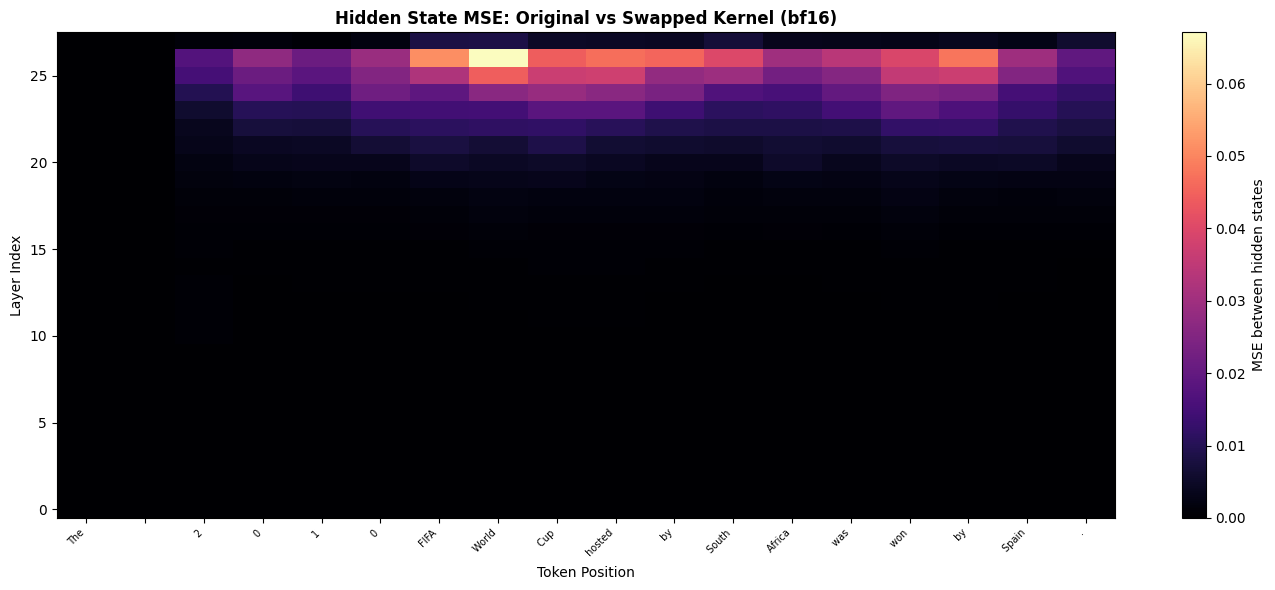

In [13]:
plot_hidden_state_heatmap(
    diff_bf16,
    title="Hidden State MSE: Original vs Swapped Kernel (bf16)",
    token_labels=token_labels,
)

We see a common pattern emerging across most of the tokens: as we go deeper into the model, starting from around the 21st layer, the MSE between the hidden states starts to accumulate and grow larger.

---

## Part 5: Does It Matter for Downstream Predictions? JS Divergence on MMLU-Pro

Let's next show that the drift in hidden states leads to drifts in the model's output distribution. We measure this directly on **[MMLU-Pro](https://huggingface.co/datasets/TIGER-Lab/MMLU-Pro)**, a multiple-choice reasoning benchmark with up to 10 options per question.

For each of 100 randomly sampled questions, we:

1. Build a prompt of the form `Question: ...\nOptions:\nA. ...\n...\nAnswer:` and run a single forward pass through both the original and the kernel-swapped model.
2. We capture the logit scores for the answer options `A`-`J` at the final LM head, and convert them to probability distributions via softmax.
3. Compute the **Jensen-Shannon divergence** between the two next-token distributions. JSD is symmetric and bounded in $[0, \ln 2 \approx 0.693]$ nats, which makes the values easy to interpret on a fixed scale: `0` means the distributions are identical, `ln 2` means they are completely disjoint.
4. Take the **argmax over the answer-letter tokens** (`A`-`J`) to get each model's predicted answer.

A swap that is "the same model" should produce near-zero JSD and identical argmax answers on every question. We'll see how close to that ideal the swapped kernel really is, and on the questions where it isn't, we'll plot the shift in answer-letter probabilities.

In [ ]:
import random

ds = load_dataset("TIGER-Lab/MMLU-Pro", split="test")
N_QUESTIONS = 100
SEED = 42

random.seed(SEED)
sampled_idx = random.sample(range(len(ds)), N_QUESTIONS)
mmlu_pro_questions = [ds[i] for i in sampled_idx]

print(f"Sampled {len(mmlu_pro_questions)} questions from MMLU-Pro")
print("\nExample question:")
ex = mmlu_pro_questions[0]
print(f"  category : {ex['category']}")
print(f"  question : {ex['question']}")
print(f"  options  : {ex['options']}")
print(f"  answer   : {ex['answer']}")

Sampled 100 questions from MMLU-Pro

Example question:
  category : computer science
  question : Bob writes down a number between 1 and 1,000. Mary must identify that number by asking "yes/no" questions of Bob. Mary knows that Bob always tells the truth. If Mary uses an optimal strategy, then she will determine the answer at the end of exactly how many questions in the worst case?
  options  : ['250', '20', '500', '100', '2', '1,000', '999', '50', '10']
  answer   : I


In [16]:
import torch.nn.functional as F

ANSWER_LETTERS = list(string.ascii_uppercase[:10])  # A..J

# Token IDs for " A", " B", ... " J" (with leading space, since the prompt ends with "Answer:")
LETTER_TOKEN_IDS = {
    L: tokenizer.encode(f" {L}", add_special_tokens=False)[0] for L in ANSWER_LETTERS
}


def format_mmlu_pro_prompt(question: dict) -> tuple[str, list[str]]:
    """Return a zero-shot prompt and the list of valid answer letters for this question."""
    letters = ANSWER_LETTERS[:len(question["options"])]
    body = "\n".join(f"{L}. {opt}" for L, opt in zip(letters, question["options"]))
    prompt = f"Question: {question['question']}\nOptions:\n{body}\nAnswer:"
    return prompt, letters


@torch.no_grad()
def next_token_logits(model, prompt: str) -> torch.Tensor:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    logits = model(**inputs).logits[0, -1]
    return logits.float().cpu()


def js_div(logits_p: torch.Tensor, logits_q: torch.Tensor) -> float:
    """Jensen-Shannon divergence (nats), bounded in [0, ln 2 = 0.6931...]."""
    log_p = F.log_softmax(logits_p, dim=-1)
    log_q = F.log_softmax(logits_q, dim=-1)
    log_m = torch.stack([log_p, log_q]).logsumexp(dim=0) - np.log(2)  # log mixture mean
    kl_pm = F.kl_div(log_m, log_p, reduction="sum", log_target=True)
    kl_qm = F.kl_div(log_m, log_q, reduction="sum", log_target=True)
    return (0.5 * (kl_pm + kl_qm)).item()


def letter_argmax(logits: torch.Tensor, letters: list[str]) -> tuple[str, dict[str, float]]:
    """Argmax restricted to valid answer letters. Returns (letter, prob-dict over letters)."""
    ids = [LETTER_TOKEN_IDS[L] for L in letters]
    probs = F.softmax(logits[ids], dim=-1)
    pick = letters[probs.argmax().item()]
    return pick, dict(zip(letters, probs.tolist()))

In [17]:
# Show what the prompt actually looks like for the first sampled question.
sample_prompt, sample_letters = format_mmlu_pro_prompt(mmlu_pro_questions[0])
print(sample_prompt)
print()
print(f"Valid answer letters: {sample_letters}")
print(f"Gold answer: {mmlu_pro_questions[0]['answer']}")

Question: Bob writes down a number between 1 and 1,000. Mary must identify that number by asking "yes/no" questions of Bob. Mary knows that Bob always tells the truth. If Mary uses an optimal strategy, then she will determine the answer at the end of exactly how many questions in the worst case?
Options:
A. 250
B. 20
C. 500
D. 100
E. 2
F. 1,000
G. 999
H. 50
I. 10
Answer:

Valid answer letters: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
Gold answer: I


In [45]:
results = []
for q in tqdm(mmlu_pro_questions, desc="MMLU-Pro: original kernel"):
    prompt, letters = format_mmlu_pro_prompt(q)
    logits = next_token_logits(model_bf16, prompt)
    pick, probs = letter_argmax(logits, letters)
    results.append({
        'prompt': prompt,
        'letters': letters,
        'gold': q['answer'],
        'orig_logits': logits,
        'orig_pick': pick,
        'orig_probs': probs,
    })

orig_fwd = patch_model_rmsnorm(model_bf16, liger_kernel_rmsnorm)
for r in tqdm(results, desc="MMLU-Pro: swapped kernel"):
    logits = next_token_logits(model_bf16, r['prompt'])
    pick, probs = letter_argmax(logits, r['letters'])
    r['swap_logits'] = logits
    r['swap_pick'] = pick
    r['swap_probs'] = probs
unpatch_model_rmsnorm(model_bf16, orig_fwd)

for r in results:
    r['jsd'] = js_div(r['orig_logits'], r['swap_logits'])

jsd_values = np.array([r['jsd'] for r in results])
print(f"\nJS divergence(P_orig, P_swap) over {len(results)} MMLU-Pro questions:")
print(f"  mean    : {jsd_values.mean():.4e}  nats")
print(f"  median  : {np.median(jsd_values):.4e}  nats")
print(f"  max     : {jsd_values.max():.4e}  nats")
print(f"  min     : {jsd_values.min():.4e}  nats")
print(f"  (upper bound: ln 2 = {np.log(2):.4f} nats)")


MMLU-Pro: original kernel: 100%|██████████| 100/100 [00:02<00:00, 41.18it/s]


Patched 113 RMSNorm modules


MMLU-Pro: swapped kernel: 100%|██████████| 100/100 [00:02<00:00, 37.53it/s]


Unpatched 113 RMSNorm modules

JS divergence(P_orig, P_swap) over 100 MMLU-Pro questions:
  mean    : 1.0699e-03  nats
  median  : 9.1873e-04  nats
  max     : 3.2707e-03  nats
  min     : 7.0100e-05  nats
  (upper bound: ln 2 = 0.6931 nats)


### Putting the JSD numbers in context

JSD is bounded in $[0, \ln 2 \approx 0.693]$ nats. With a mean JSD of `1.07e-3`, we can conclude that **while the output distributions are very close, they are not identical.** Next, let's quantify how much the probability mass shifted between the original and swapped models for the answer options `A`-`J`:

Mean of per-question mean |delta prob| (all 100 questions) : 6.7675e-03
  unchanged (n=95)                                : 6.7427e-03
  flipped   (n=5)                                 : 7.2382e-03


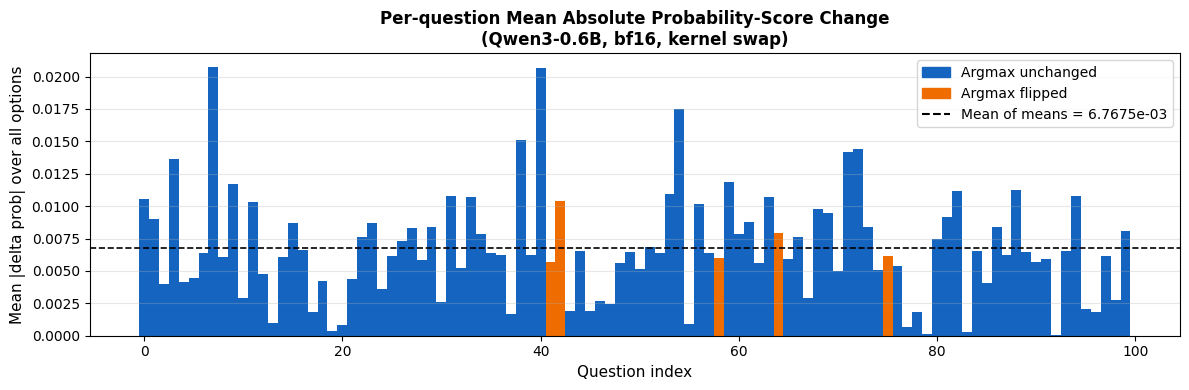

In [47]:
# For each question compute mean absolute delta prob across its answer letters.
question_mean_abs_delta = []
for r in results:
    ids = [LETTER_TOKEN_IDS[L] for L in r['letters']]
    orig_p = F.softmax(r['orig_logits'][ids], dim=-1).numpy()
    swap_p = F.softmax(r['swap_logits'][ids], dim=-1).numpy()
    question_mean_abs_delta.append(np.abs(swap_p - orig_p).mean())

question_mean_abs_delta = np.array(question_mean_abs_delta)
unchanged_mask = np.array([r['orig_pick'] == r['swap_pick'] for r in results])

print(f"Mean of per-question mean |delta prob| (all {len(results)} questions) : {question_mean_abs_delta.mean():.4e}")
print(f"  unchanged (n={unchanged_mask.sum()})                                : {question_mean_abs_delta[unchanged_mask].mean():.4e}")
print(f"  flipped   (n={(~unchanged_mask).sum()})                                 : {question_mean_abs_delta[~unchanged_mask].mean():.4e}")

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#EF6C00' if not u else '#1565C0' for u in unchanged_mask]
ax.bar(range(len(results)), question_mean_abs_delta, color=colors, edgecolor='none', width=1.0)
ax.axhline(question_mean_abs_delta.mean(), color='black', linewidth=1.2, linestyle='--')
unchanged_patch = mpatches.Patch(color='#1565C0', label='Argmax unchanged')
flipped_patch   = mpatches.Patch(color='#EF6C00', label='Argmax flipped')
mean_line       = plt.Line2D([0], [0], color='black', linestyle='--',
                              label=f'Mean of means = {question_mean_abs_delta.mean():.4e}')
ax.legend(handles=[unchanged_patch, flipped_patch, mean_line], fontsize=10)
ax.set_xlabel("Question index", fontsize=11)
ax.set_ylabel("Mean |delta prob| over all options", fontsize=11)
ax.set_title("Per-question Mean Absolute Probability-Score Change\n(Qwen3-0.6B, bf16, kernel swap)", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('mmlu_pro_prob_change.png', dpi=150, bbox_inches='tight')
plt.show()


We see that, on average, the probability score of any given option changed by only `0.007`, i.e., `0.7%`. However, even a small shift like this can change the argmax answer if the original probabilities were close to each other, which is what results in the 5 flipped answers we see in the next section.

In [38]:
n_flipped = sum(1 for r in results if r['orig_pick'] != r['swap_pick'])
print(f"\nArgmax answer flipped: {n_flipped} / {len(results)} questions")

orig_correct = sum(1 for r in results if r['orig_pick'] == r['gold'])
swap_correct = sum(1 for r in results if r['swap_pick'] == r['gold'])
n = len(results)
print(f"\nAccuracy (original kernel) : {orig_correct}/{n}  ({100 * orig_correct / n:.1f}%)")
print(f"Accuracy (swapped kernel)  : {swap_correct}/{n}  ({100 * swap_correct / n:.1f}%)")
print(f"Accuracy delta             : {swap_correct - orig_correct:+d}  ({100 * (swap_correct - orig_correct) / n:+.1f}%)")


Argmax answer flipped: 5 / 100 questions

Accuracy (original kernel) : 23/100  (23.0%)
Accuracy (swapped kernel)  : 24/100  (24.0%)
Accuracy delta             : +1  (+1.0%)


### Accuracy and Flipped Responses

We also see that the model **flipped 5 of its responses when we swapped the kernel, and the accuracy of the model improved by 1%**. This shows us that it is important to re-benchmark a model, especially with the same set of kernels that will be used in production, to get an accurate estimate of the model's performance.

Let's look at the 5 questions where the argmax answer flipped, and see how the answer-letter probabilities shifted for those questions:

In [ ]:
flipped = [r for r in results if r['orig_pick'] != r['swap_pick']]

rows = []
for r in flipped:
    a, b = r['orig_pick'], r['swap_pick']
    rows.append({
        'orig_pick': a,
        'swap_pick': b,
        'delta_orig': r['swap_probs'][a] - r['orig_probs'][a],
        'delta_swap': r['swap_probs'][b] - r['orig_probs'][b],
    })

n = len(rows)
x = np.arange(n)
w = 0.4

fig, ax = plt.subplots(figsize=(max(8, 1.5 * n), 5))

ax.bar(x - w/2, [r['delta_orig'] for r in rows], w,
       color='#1565C0', edgecolor='black', linewidth=0.6,
       label='Delta P(original answer)  =  P_swap - P_orig')
ax.bar(x + w/2, [r['delta_swap'] for r in rows], w,
       color='#EF6C00', edgecolor='black', linewidth=0.6,
       label='Delta P(new answer)       =  P_swap - P_orig')

ax.axhline(0, color='black', linewidth=0.8)
labels = [f"{r['orig_pick']}->{r['swap_pick']}" for r in rows]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_xlabel("Flipped questions  (original pick -> swapped pick)", fontsize=11)
ax.set_ylabel("Change in probability (renormalised over answer letters)", fontsize=11)
ax.set_title(
    "Probability Change on Argmax-Flipped Questions\n(Qwen3-0.6B, bf16)",
    fontsize=12, fontweight='bold',
)
ax.legend(fontsize=10, loc='best')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('mmlu_pro_flipped_probs.png', dpi=150, bbox_inches='tight')
plt.show()


We observe that for the questions corresponding to the flipped answers, the original model had two or more answer options with close probabilities, and the kernel swap caused a 2-3% shift in those probabilities, which was enough to change the argmax answer. **This highlights that using confidence/margin-based token selection methods might be more robust than simple argmax selection in the presence of kernel-induced perturbations.**

---

## Conclusion

In our experiments, we show that swapping a kernel can lead to different outputs even with greedy decoding. This means that the "kernels" being used in a production model served to customers can exhibit different behavior than the kernels being tested in isolation or evaluated during model training. This makes **kernels** another axis for benchmarking model behavior/outputs.

We also bring to light that kernel accuracy tests that rely on artificial inputs sampled from normal distributions may not be the best way to test the correctness of a kernel. **Kernel engineers should create tests that realistically represent inputs/activations with outliers and weights with distributions observed in trained models.**

Post-training algorithms that involve using a reference/teacher model with frozen weights served via an external inference library often include an importance-sampling factor to correct for distribution shifts between the reference and student models **that stem from inference engines using different kernels compared to the ones used in the training pipeline.**

### Future Directions

Some other areas to explore include:
* An interesting idea worth exploring is whether we can develop a _kernel-aware_ training algorithm, in the spirit of _quantization-aware_ training, where a model is trained to be robust to perturbations introduced by swapping in different kernels.
* Identifying which kernels/operations are more "sensitive" to swapping than others, and prioritizing those for kernel engineering efforts.
* Evaluating how model depth affects sensitivity to kernel swapping. Are deeper models more sensitive due to more layers of error accumulation?
* Exploring how errors accumulate when swapping multiple kernels at the same time, which is more representative of a real deployment scenario where all kernels are swapped together.